## Pertanyaan Bisnis
1. Berapa total nominal dan jumlah transaksi kategori makanan & minuman serta transportasi di bawah Rp100.000 oleh persona anak_kos dan mahasiswa setiap bulan selama 2024–2025, serta bagaimana tren pengeluarannya?
2. Kategori pengeluaran apa yang paling besar rata-rata kontribusinya terhadap total belanja bulanan untuk tiap persona (anak_kos, mahasiswa, karyawan) selama 2024, dan kapan biasanya pengeluaran itu meningkat tajam dalam sebulan?
3. Apa 3 metode pembayaran digital yang paling sering digunakan oleh generasi muda (anak_kos, mahasiswa, anak_sultan) saat bertransaksi nontunai di merchant seperti Miniso dan Gacoan pada Q4 2024?


## Import Packages/Library

In [6]:
!pip install faker

import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import re

fake = Faker("id_ID")

random.seed(42)

## Data Wrangling

### Gathering Data

In [7]:
personal_df = pd.read_excel("https://github.com/PatriciaRoellina/Financial-Transaction-Description-Dataset/raw/refs/heads/main/Personal%20Finance%20Dataset.xlsx")
personal_df.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01


In [8]:
nlp_df = pd.read_csv("https://github.com/PatriciaRoellina/Financial-Transaction-Description-Dataset/raw/refs/heads/main/Auto-Categorization%20(NLP).csv")
nlp_df.head()

,transaction_text,category
0,Flipkart order INR 22831 TXN684df950,shopping
1,Electronics shopping INR 28634 TXNd8965185,shopping
2,Netflix subscription INR 33127 TXN6001238b,entertainment
3,Credit card EMI INR 33532 TXNd9902ece,emi
4,Stock purchase INR 44652 TXN08b5169f,investment


In [9]:
anomaly_df = pd.read_csv("https://github.com/PatriciaRoellina/Financial-Transaction-Description-Dataset/raw/refs/heads/main/Anomaly%20Detection%20(Deteksi%20Boros).csv")
anomaly_df.head()

,date,category,amount
0,2022-07-06 05:57:10 +0000,Restuarant,5.50
1,2022-07-06 05:57:27 +0000,Market,2.00
2,2022-07-06 05:58:12 +0000,Coffe,30.10
3,2022-07-06 05:58:25 +0000,Market,17.33
4,2022-07-06 05:59:00 +0000,Restuarant,5.50


In [10]:
kb = pd.read_excel("Data_Scrap_FIX_Final.xlsx")
kb.head()

,merchant,item,kategori,nominal
0,Shopee Official Store,Pasta Gigi Premium Quality,Kebersihan & Perawatan,54000
1,Shopee Official Store,KOPI BUBUK TUBRUK VANILLA 150g,Makanan & Minuman,162798
2,Dettol Official,Dettol Sabun Antiseptik 250ml,Kebersihan & Perawatan,41000
3,Shopee Official Store,Sepatu Sneakers Premium Quality,Fashion,57000
4,Shinzui Official,Shinzui Body Cleanser Sakura,Kebersihan & Perawatan,34000


### Assessing Data

In [11]:
print("\nInfo personal_df:")
print(personal_df.info())
print("\nDescribe personal_df:")
print(personal_df.describe())
print("\nMissing values di personal_df:")
print(personal_df.isna().sum())
print("\nJumlah duplikasi:", personal_df.duplicated().sum())


Info personal_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account Name      806 non-null    object        
 6   Month             806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 44.2+ KB
None

Describe personal_df:
                                Date       Amount
count                            806   806.000000
mean   2018-11-12 00:00:00.000000256   273.391489
min              2018-01-01 00:00:00     1.750000
25%              2018-06-03 06:00:00    15.687500
50%              2018-11-11 00:00:00    3

In [12]:
print("\nInfo nlp_df:")
print(nlp_df.info())
print("\nDescribe nlp_df:")
print(nlp_df.describe())
print("\nMissing values di nlp_df:")
print(nlp_df.isna().sum())
print("\nJumlah duplikasi:", nlp_df.duplicated().sum())


Info nlp_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_text  1000 non-null   object
 1   category          1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB
None

Describe nlp_df:
                              transaction_text category
count                                     1000     1000
unique                                    1000        9
top     Crypto investment INR 5216 TXNe8c7dec7      emi
freq                                         1      121

Missing values di nlp_df:
transaction_text    0
category            0
dtype: int64

Jumlah duplikasi: 0


In [13]:
print("\nInfo anomaly_df:")
print(anomaly_df.info())
print("\nDescribe anomaly_df:")
print(anomaly_df.describe())
print("\nMissing values di anomaly_df:")
print(anomaly_df.isna().sum())
print("\nJumlah duplikasi:", anomaly_df.duplicated().sum())


Info anomaly_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4597 entries, 0 to 4596
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      4597 non-null   object 
 1   category  4597 non-null   object 
 2   amount    4597 non-null   float64
dtypes: float64(1), object(2)
memory usage: 107.9+ KB
None

Describe anomaly_df:
            amount
count  4597.000000
mean     15.591100
std      75.778464
min       0.050000
25%       4.000000
50%       7.100000
75%      11.500000
max    2500.000000

Missing values di anomaly_df:
date        0
category    0
amount      0
dtype: int64

Jumlah duplikasi: 0


In [14]:
print("\nInfo data scraping:")
print(kb.info())
print("\nDescribe data scraping:")
print(kb.describe())
print("\nMissing values di data scraping:")
print(kb.isna().sum())
print("\nJumlah duplikasi:", kb.duplicated().sum())


Info data scraping:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   merchant  656 non-null    object
 1   item      656 non-null    object
 2   kategori  656 non-null    object
 3   nominal   656 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 20.6+ KB
None

Describe data scraping:
             nominal
count     656.000000
mean    52307.132622
std     68774.561735
min       500.000000
25%     14000.000000
50%     33000.000000
75%     61837.500000
max    850000.000000

Missing values di data scraping:
merchant    0
item        0
kategori    0
nominal     0
dtype: int64

Jumlah duplikasi: 104


**Insight:**
- Dataset awal diperoleh dari platform Kaggle yang berisi data transaksi, auto categorization, dan anomaly detection untuk memahami struktur data personal finance serta pola kategorisasi transaksi.
- Setelah dilakukan proses Gathering dan Assessing Data, ditemukan bahwa sebagian besar dataset masih didominasi oleh merchant dan item transaksi internasional sehingga kurang merepresentasikan perilaku transaksi pengguna di Indonesia.
- Beberapa dataset masih menggunakan account name dan transaction label yang terlalu umum seperti “platinum”, “silver card”, dan label transaksi perbankan lainnya yang kurang menggambarkan aktivitas pengeluaran harian pengguna secara realistis.
- Sebagian besar hanya menyediakan kolom deskripsi transaksi umum tanpa detail item transaksi yang spesifik.

**Recomendation**
- Mengembangkan knowledge base berbasis merchant dan item lokal Indonesia melalui proses scraping dan pembaruan data secara berkala agar model AI tetap relevan terhadap tren transaksi terbaru.
- Menggunakan synthetic behavioral generation untuk mensimulasikan perilaku transaksi pengguna karena data personal finance asli bersifat privat dan sulit diperoleh secara publik.
- Menambahkan variasi merchant, item, dan kategori transaksi agar model mampu melakukan generalisasi terhadap transaksi baru yang belum pernah muncul pada dataset training.
- Melakukan feature engineering seperti combined text generation untuk membantu model memahami konteks transaksi secara lebih baik.

### Synthetic Behavioral Generation

In [15]:
user_personas = {

    "U001": {
        "persona": "anak_kos",
        "favorite_categories": [
            "Makanan & Minuman",
            "Transportasi",
            "Kebutuhan Rumah",
            "Transport"
        ]
    },

    "U002": {
        "persona": "karyawan",
        "favorite_categories": [
            "Makanan & Minuman",
            "Hiburan",
            "Belanja",
            "Transport"
        ]
    },

    "U003": {
        "persona": "mahasiswa",
        "favorite_categories": [
            "Makanan & Minuman",
            "Transportasi",
            "Pendidikan",
            "Transport"
        ]
    },

    "U004": {
        "persona": "ibu_rumah_tangga",
        "favorite_categories": [
            "Kebutuhan Rumah",
            "Kesehatan",
            "Tagihan & Utilitas"
        ]
    },

    "U005": {
        "persona": "anak_sultan",
        "favorite_categories": [
            "Belanja",
            "Hiburan",
            "Makanan & Minuman"
        ]
    }

}

# 4. DATE RANGE

start_date = datetime(2024, 1, 1)
end_date = datetime(2025, 12, 31)

# 5. GENERATE TRANSACTIONS

transactions = []

for user_id, profile in user_personas.items():

    persona = profile["persona"]
    favorite_categories = profile["favorite_categories"]

    total_transactions = random.randint(1200, 1800)

    print(f"Generating {total_transactions} transactions for {user_id}")

    for _ in range(total_transactions):

        # RANDOM CATEGORY

        kategori = random.choice(favorite_categories)

        # FILTER KNOWLEDGE BASE

        filtered_kb = kb[
            kb["kategori"] == kategori
        ]

        if len(filtered_kb) == 0:
            continue

        # RANDOM ITEM FROM KB

        selected = filtered_kb.sample(1).iloc[0]

        merchant = selected["merchant"]
        item = selected["item"]

        # BASE NOMINAL

        base_nominal = selected["nominal"]

        # QTY REALISM

        if kategori == "Makanan & Minuman":
            qty = random.randint(1, 2)

        elif kategori == "Kebutuhan Rumah":
            qty = random.randint(1, 5)

        elif kategori == "Belanja":
            qty = random.randint(1, 3)

        else:
            qty = 1

        # NOMINAL VARIATION

        nominal = int(
            base_nominal * random.uniform(0.9, 1.1)
        )

        total_harga = nominal * qty

        # RANDOM DATE

        random_days = random.randint(
            0,
            (end_date - start_date).days
        )

        random_minutes = random.randint(0, 1440)

        transaction_date = (
            start_date
            + timedelta(days=random_days)
            + timedelta(minutes=random_minutes)
        )

        # PAYMENT METHOD

        payment_method = random.choice([
            "QRIS",
            "Cash",
            "Debit Card",
            "GoPay",
            "OVO",
            "DANA"
        ])

        # SAVE TRANSACTION

        transactions.append({

            "user_id": user_id,

            "persona": persona,

            "date": transaction_date,

            "merchant": merchant,

            "item": item,

            "kategori": kategori,

            "qty": qty,

            "nominal": nominal,

            "total_harga": total_harga,

            "payment_method": payment_method

        })

# 6. FINAL DATAFRAME

final_df = pd.DataFrame(transactions)

# 7. SORT BY DATE

final_df = final_df.sort_values(
    by="date"
).reset_index(drop=True)

# 8. PREVIEW

print(final_df.head())

print("\nTOTAL ROWS:")
print(len(final_df))

print("\nCATEGORY DISTRIBUTION:")
print(final_df["kategori"].value_counts())

print("\nDATASET SUCCESSFULLY GENERATED!")

Generating 1314 transactions for U001
Generating 1664 transactions for U002
Generating 1248 transactions for U003
Generating 1781 transactions for U004
Generating 1204 transactions for U005
  user_id           persona                date      merchant  \
0    U001          anak_kos 2024-01-01 01:10:00     Traveloka   
1    U004  ibu_rumah_tangga 2024-01-01 02:13:00  Simply Fresh   
2    U004  ibu_rumah_tangga 2024-01-01 02:49:00   First Media   
3    U004  ibu_rumah_tangga 2024-01-01 04:40:00        Miniso   
4    U002          karyawan 2024-01-01 05:13:00       Spotify   

                                                item            kategori  qty  \
0                             Tiket Pesawat Domestik           Transport    1   
1                                    Laundry Express     Kebutuhan Rumah    3   
2                                   Tagihan TV Kabel  Tagihan & Utilitas    1   
3  MINISO Memory Foam U-Shape Bantal Leher Mickey...     Kebutuhan Rumah    1   
4             

**Insight**
- Dibangun knowledge base berbasis merchant lokal Indonesia melalui proses web scraping dan manual curation. Merchant yang ditambahkan mencakup berbagai aktivitas transaksi sehari-hari seperti:
  - makanan dan minuman (mixue, kopi kenangan, mie gacoan, warmindo)
  - transportasi online (gojek, grab)
  - hiburan digital (netflix, spotify, cgv, xxi)
  - minimarket dan kebutuhan rumah (indomaret, superindo, miniso)
  - utilitas dan kesehatan (pln, pdam, pertamina, k24)
  - e-commerce (shopee)
- Synthetic generation tidak hanya menghasilkan transaksi secara acak, tetapi juga mensimulasikan perilaku pengguna berdasarkan persona tertentu agar pola transaksi lebih realistis. Sebagai contoh:
  - persona mahasiswa dan anak kos lebih sering melakukan transaksi pada merchant seperti gojek, mixue, warmindo, mie gacoan, dan indomaret dengan nominal kecil namun frekuensi tinggi.
  - persona karyawan memiliki kecenderungan transaksi pada miniso, grab, netflix, dan shopee dengan pola pengeluaran menengah.
  - persona ibu rumah tangga lebih sering melakukan transaksi kebutuhan rumah tangga seperti supermarket, aqua, pln, pertamina, dan k24.
- Synthetic dataset juga dibuat lebih realistis dengan menambahkan variasi:
  - metode pembayaran digital seperti gopay, ovo, dana, dan qris
  - waktu transaksi
  - kategori waktu transaksi (morning, afternoon, evening, night)
  - quantity pembelian berdasarkan jenis merchant
  - variasi nominal transaksi
- Selain merchant lokal, detail item transaksi juga dibuat lebih spesifik. Contohnya:
  - goride
  - netflix premium bulanan
  - pertalite
  - kopi susu gula aren
- Pendekatan ini menghasilkan dataset yang lebih representatif terhadap pola pengeluaran masyarakat Indonesia

### Cleaning Data

In [16]:
df = final_df.copy()

# 1. LOWERCASE

df["merchant"] = df["merchant"].str.lower()
df["item"] = df["item"].str.lower()
df["kategori"] = df["kategori"].str.lower()

# CLEAN MERCHANT

df["merchant"] = (
    df["merchant"]
    .apply(
        lambda x: re.sub(
            r"[^a-zA-Z0-9 ]",
            " ",
            str(x)
        )
    )
)

# CLEAN ITEM

df["item"] = (
    df["item"]
    .apply(
        lambda x: re.sub(
            r"[^a-zA-Z0-9 ]",
            " ",
            str(x)
        )
    )
)

# REMOVE EXTRA SPACES

df["merchant"] = (
    df["merchant"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["item"] = (
    df["item"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 3. COMBINE TEXT

df["combined_text"] = (
    df["merchant"] + " " + df["item"]
)

# 4. REMOVE SPECIAL CHARACTERS

df["combined_text"] = (
    df["combined_text"]
    .apply(
        lambda x: re.sub(
            r"[^a-zA-Z0-9 ]",
            "",
            str(x)
        )
    )
)

# 5. REMOVE EXTRA SPACES

df["combined_text"] = (
    df["combined_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 6. REMOVE DUPLICATES

df = df.drop_duplicates()

# 7. HANDLE MISSING VALUES

df = df.dropna()

# 8. CONVERT DATE

df["date"] = pd.to_datetime(df["date"])

# 9. RESET INDEX

df = df.reset_index(drop=True)

# 10. PREVIEW

print(df.head())

print("\nDATASET SHAPE:")
print(df.shape)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDUPLICATE CHECK:")
print(df.duplicated().sum())

# 11. SAVE PREPROCESSED DATASET

df.to_csv(
    "preprocessed_finance_dataset.csv",
    index=False
)

df.to_excel(
    "preprocessed_finance_dataset.xlsx",
    index=False
)

print("\nPREPROCESSING SUCCESSFULLY COMPLETED!")

  user_id           persona                date      merchant  \
0    U001          anak_kos 2024-01-01 01:10:00     traveloka   
1    U004  ibu_rumah_tangga 2024-01-01 02:13:00  simply fresh   
2    U004  ibu_rumah_tangga 2024-01-01 02:49:00   first media   
3    U004  ibu_rumah_tangga 2024-01-01 04:40:00        miniso   
4    U002          karyawan 2024-01-01 05:13:00       spotify   

                                                item            kategori  qty  \
0                             tiket pesawat domestik           transport    1   
1                                    laundry express     kebutuhan rumah    3   
2                                   tagihan tv kabel  tagihan & utilitas    1   
3  miniso memory foam u shape bantal leher mickey...     kebutuhan rumah    1   
4                         spotify premium individual             hiburan    1   

   nominal  total_harga payment_method  \
0   928170       928170     Debit Card   
1    36321       108963          GoPay

**Insight**
- Cleaning data dilakukan pada synthetic behavioral dataset untuk meningkatkan kualitas dan konsistensi data sebelum digunakan pada proses exploratory data analysis dan AI modeling.
- Proses normalisasi teks dilakukan dengan mengubah seluruh nilai pada kolom merchant, item, kategori, dan payment_method menjadi lowercase. Langkah ini bertujuan untuk menghindari perbedaan penulisan seperti “GoRide” dan “goride” yang sebenarnya merepresentasikan transaksi yang sama.
- Pembersihan karakter khusus dilakukan menggunakan regular expression untuk menghapus simbol yang tidak relevan seperti |, -, +, (, ), dan karakter non-alfanumerik lainnya. Proses ini bertujuan untuk mengurangi noise pada data teks sehingga model NLP lebih mudah memahami pola transaksi.
- Proses normalisasi spasi dilakukan untuk menghapus double spacing dan merapikan format teks setelah karakter khusus dihapus. Hal ini bertujuan untuk menjaga konsistensi token pada proses text preprocessing.
- Pembuatan kolom combined_text dilakukan dengan menggabungkan kolom merchant dan item transaksi agar model AI dapat memahami konteks transaksi secara lebih lengkap.
- Duplicate removal dilakukan untuk menghapus data transaksi yang memiliki informasi identik sehingga dapat mengurangi redundansi data pada proses training model.
- Missing value handling dilakukan dengan menghapus data yang memiliki nilai kosong agar proses analisis dan modeling tidak terganggu oleh data yang tidak lengkap.
- Konversi tipe data pada kolom date dilakukan menggunakan format datetime agar data waktu transaksi dapat digunakan pada proses analisis temporal dan feature engineering.
- Tahap cleaning data bertujuan untuk menghasilkan dataset yang lebih konsisten, minim noise, dan siap digunakan pada proses exploratory data analysis, serta pengembangan model AI personal finance.

## Exploratory Data Analysis (EDA)

In [17]:
dataset_df = pd.read_csv("preprocessed_finance_dataset.csv")
dataset_df.sample(5)

,user_id,persona,date,merchant,item,kategori,qty,nominal,total_harga,payment_method,combined_text
568,U005,anak_sultan,2024-03-05 14:23:00,miniso,miniso tas selempang wanita handbag crossbody ...,belanja,3,97548,292644,Cash,miniso miniso tas selempang wanita handbag cro...
1605,U005,anak_sultan,2024-06-23 09:13:00,miniso,miniso parfum wanita 30ml dreamland eau de toi...,belanja,3,55966,167898,QRIS,miniso miniso parfum wanita 30ml dreamland eau...
205,U005,anak_sultan,2024-01-23 02:42:00,miniso,miniso resmi masker mata telinga kucing lucu m...,belanja,3,31932,95796,Cash,miniso miniso resmi masker mata telinga kucing...
5279,U002,karyawan,2025-08-10 18:59:00,steam,top up steam wallet,hiburan,1,131732,131732,Cash,steam top up steam wallet
771,U002,karyawan,2024-03-28 17:52:00,eparking,bayar parkir digital,transport,1,5134,5134,DANA,eparking bayar parkir digital


In [18]:
print('\nDeskripsi Tabel:')
print(dataset_df.describe(include="all"))


Deskripsi Tabel:
       user_id           persona                 date merchant        item  \
count     6573              6573                 6573     6573        6573   
unique       5                 5                 6555       58         278   
top       U004  ibu_rumah_tangga  2024-03-06 21:03:00   miniso  aqua 600ml   
freq      1781              1781                    2     1553         103   
mean       NaN               NaN                  NaN      NaN         NaN   
std        NaN               NaN                  NaN      NaN         NaN   
min        NaN               NaN                  NaN      NaN         NaN   
25%        NaN               NaN                  NaN      NaN         NaN   
50%        NaN               NaN                  NaN      NaN         NaN   
75%        NaN               NaN                  NaN      NaN         NaN   
max        NaN               NaN                  NaN      NaN         NaN   

                 kategori          qty       

In [19]:

desc = dataset_df[['nominal', 'total_harga', 'qty']].describe()
print(desc.map(lambda x: f"{x:,.0f}"))
print()

       nominal total_harga    qty
count    6,573       6,573  6,573
mean    75,956     104,919      2
std    111,227     138,680      1
min        451         451      1
25%     17,391      23,482      1
50%     52,354      65,332      1
75%     93,999     121,256      2
max    928,941   1,069,749      5



/tmp/ipykernel_11697/2216615204.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='nominal', y='kategori', palette=sns.color_palette(PALETTE_CAT, 6),


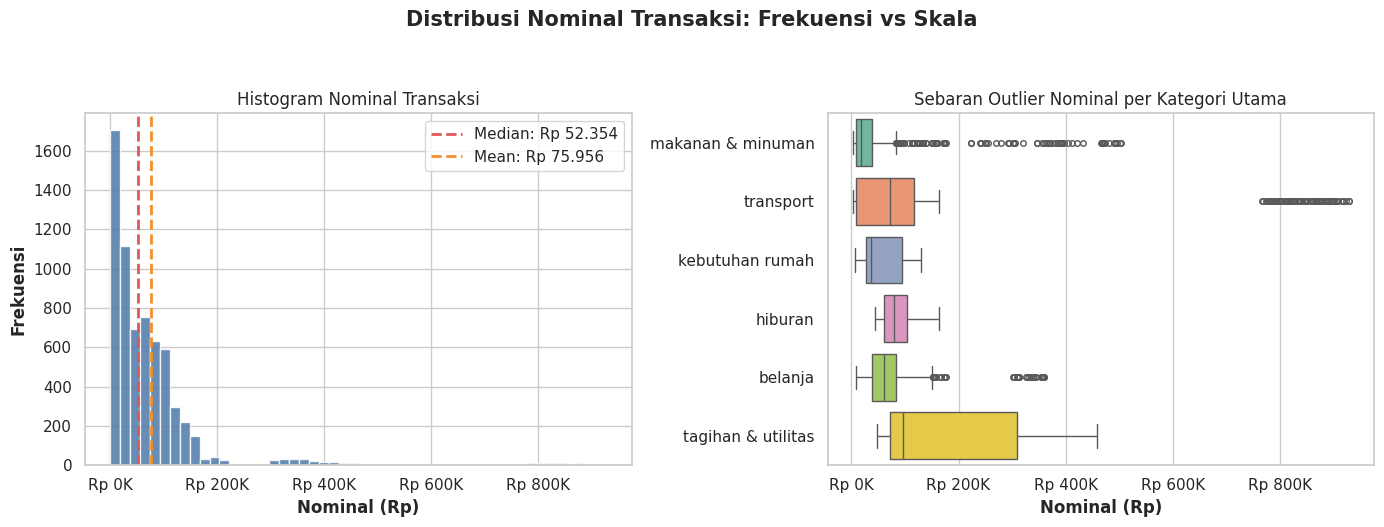

In [20]:
def rupiah(val):
    """Format angka menjadi string Rupiah."""
    return f"Rp {val:,.0f}".replace(',', '.')

def fmt_rupiah(x, pos=None):
    """Formatter untuk axis Matplotlib (skala Ribuan/Jutaan)."""
    if x >= 1e6:
        return f"Rp {x/1e6:,.1f}M".replace(',', '.')
    return f"Rp {x/1e3:,.0f}K".replace(',', '.')

PALETTE_CAT = "Set2"
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Nominal Transaksi: Frekuensi vs Skala', fontsize=15, fontweight='bold', y=1.05)

axes[0].hist(dataset_df['nominal'], bins=50, color='#4E79A7', edgecolor='white', alpha=0.85)
axes[0].axvline(dataset_df['nominal'].median(), color='#E15759', linestyle='--', linewidth=2,
                label=f"Median: {rupiah(dataset_df['nominal'].median())}")
axes[0].axvline(dataset_df['nominal'].mean(), color='#F28E2B', linestyle='--', linewidth=2,
                label=f"Mean: {rupiah(dataset_df['nominal'].mean())}")
axes[0].set_xlabel('Nominal (Rp)', fontweight='bold')
axes[0].set_ylabel('Frekuensi', fontweight='bold')
axes[0].set_title('Histogram Nominal Transaksi', fontsize=12)
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

top6_kat = dataset_df['kategori'].value_counts().head(6).index.tolist()
df_box = dataset_df[dataset_df['kategori'].isin(top6_kat)]
sns.boxplot(data=df_box, x='nominal', y='kategori', palette=sns.color_palette(PALETTE_CAT, 6),
            ax=axes[1], order=top6_kat, fliersize=4)
axes[1].set_title('Sebaran Outlier Nominal per Kategori Utama', fontsize=12)
axes[1].set_xlabel('Nominal (Rp)', fontweight='bold')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

plt.tight_layout()
plt.show()


In [21]:
Q1 =dataset_df['total_harga'].quantile(0.25)
Q3 =dataset_df['total_harga'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomali_iqr =dataset_df[(dataset_df['total_harga'] < lower_bound) | (dataset_df['total_harga'] > upper_bound)]
print(f"Batas atas pengeluaran normal: Rp{upper_bound:,.0f}")

Batas atas pengeluaran normal: Rp267,917


**Insight**:
- Distribusi nominal transaksi menunjukkan pola right-skewed, di mana sebagian besar transaksi berada pada nominal rendah. Hal ini terlihat dari perbedaan antara median sebesar Rp53.504 dan rata-rata sebesar Rp75.651, yang menunjukkan bahwa mayoritas transaksi bernilai kecil namun terdapat sejumlah transaksi bernilai tinggi yang menarik rata-rata ke atas.
- Fenomena ini mengindikasikan adanya micro-spending, yaitu pengeluaran kecil yang dilakukan secara berulang. Meskipun nilai setiap transaksi relatif rendah, akumulasinya berpotensi menjadi sumber kebocoran keuangan yang sulit disadari pengguna.
- Hasil analisis menggunakan metode Interquartile Range (IQR) menunjukkan bahwa batas atas transaksi yang masih berada dalam rentang normal adalah sebesar Rp266.949. Nilai tersebut hampir 5 kali lebih besar dibanding median transaksi pengguna. Temuan ini memperkuat adanya sejumlah transaksi bernilai tinggi yang berada jauh di atas pola pengeluaran mayoritas pengguna.
- Keberadaan outlier tersebut juga terlihat pada boxplot, terutama pada kategori transport, tagihan & utilitas, dan makanan & minuman. Kondisi ini menunjukkan bahwa selain transaksi rutin bernilai kecil, terdapat pula transaksi bernilai besar yang dapat memberikan dampak signifikan terhadap total pengeluaran bulanan.

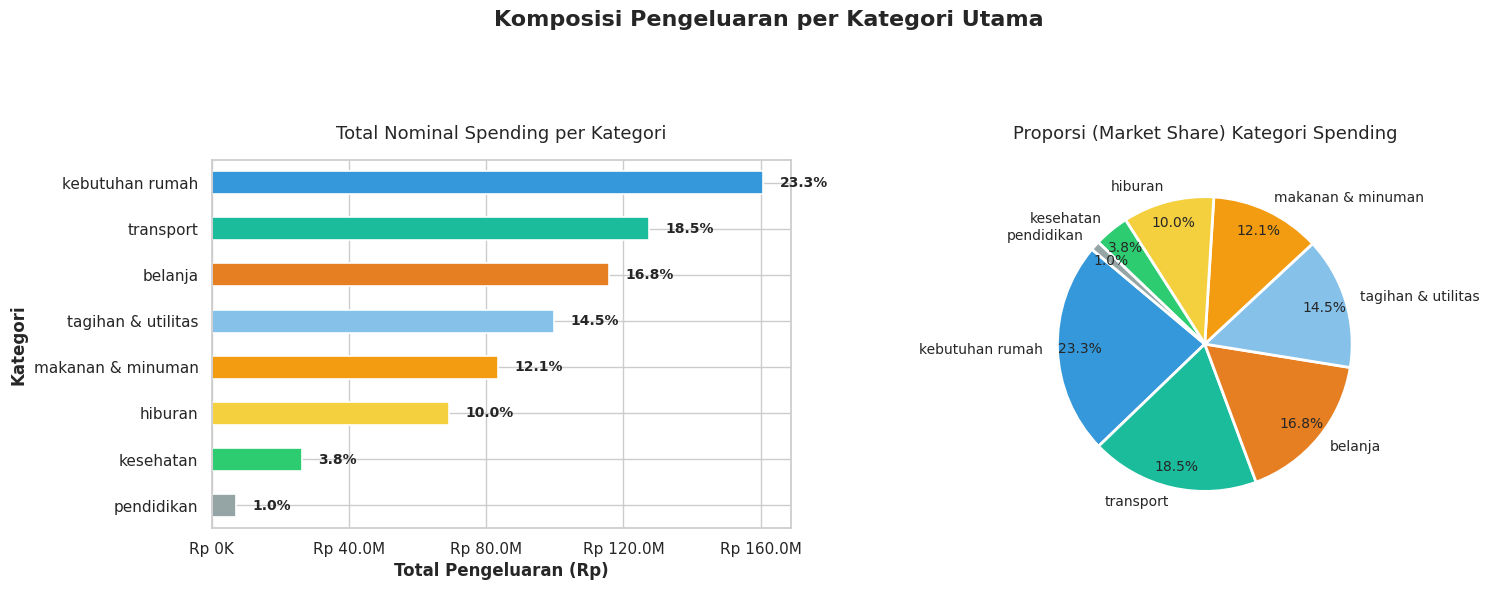

In [22]:
kat_sum  = dataset_df.groupby('kategori')['total_harga'].sum().sort_values(ascending=True)
kat_pct  = (kat_sum / kat_sum.sum() * 100).round(2)
color_map = {
    'kebutuhan rumah': '#3498DB',
    'tagihan & utilitas': '#85C1E9',

    'belanja': '#E67E22',
    'makanan & minuman': '#F39C12',
    'hiburan': '#F4D03F',

    'transport': '#1ABC9C',
    'kesehatan': '#2ECC71',
    'pendidikan': '#95A5A6'
}

bar_colors = [color_map.get(cat, '#CCCCCC') for cat in kat_sum.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Komposisi Pengeluaran per Kategori Utama", fontsize=16, fontweight='bold', y=1.02)
kat_sum.plot(kind='barh', ax=axes[0], color=bar_colors, edgecolor='white', linewidth=1.2)

for i, (v, p) in enumerate(zip(kat_sum.values, kat_pct.values)):
    axes[0].text(v + kat_sum.max() * 0.03, i, f"{p:.1f}%", va='center', fontsize=10, fontweight='bold')

axes[0].set_title("Total Nominal Spending per Kategori", fontsize=13, pad=15)
axes[0].set_xlabel("Total Pengeluaran (Rp)", fontweight='bold')
axes[0].set_ylabel("Kategori", fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

kat_sum_desc = kat_sum.sort_values(ascending=False)
pie_colors = [color_map.get(cat, '#CCCCCC') for cat in kat_sum_desc.index]

axes[1].pie(kat_sum_desc.values, labels=kat_sum_desc.index, autopct='%1.1f%%', startangle=140,
            colors=pie_colors, pctdistance=0.85, textprops={'fontsize': 10},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Proporsi (Market Share) Kategori Spending", fontsize=13, pad=15)

plt.tight_layout(pad=2.5)
plt.show()

**Insight**
- Analisis komposisi pengeluaran menunjukkan bahwa kategori kebutuhan rumah menjadi kontributor terbesar terhadap total pengeluaran dengan proporsi 24,2% atau sekitar Rp166 juta, diikuti oleh transport (19,3%) dan belanja (17,0%).
- Jika digabungkan, tiga kategori terbesar tersebut menyumbang sekitar 60,5% dari total pengeluaran, yang menunjukkan bahwa sebagian besar arus kas pengguna terkonsentrasi pada kebutuhan rumah tangga, mobilitas, dan aktivitas belanja.
- Kategori makanan & minuman hanya menyumbang 11,0% dari total nominal pengeluaran, namun pada analisis sebelumnya tercatat sebagai salah satu kategori dengan frekuensi transaksi tertinggi. Hal ini mengindikasikan bahwa kategori tersebut didominasi oleh transaksi kecil yang dilakukan secara berulang, sehingga berpotensi menjadi sumber micro-spending yang sering luput dari perhatian pengguna.
- Temuan ini menunjukkan bahwa strategi pengelolaan keuangan tidak hanya perlu berfokus pada kategori dengan nominal terbesar, tetapi juga pada kategori dengan frekuensi transaksi tinggi karena keduanya sama-sama berkontribusi terhadap pengeluaran bulanan.

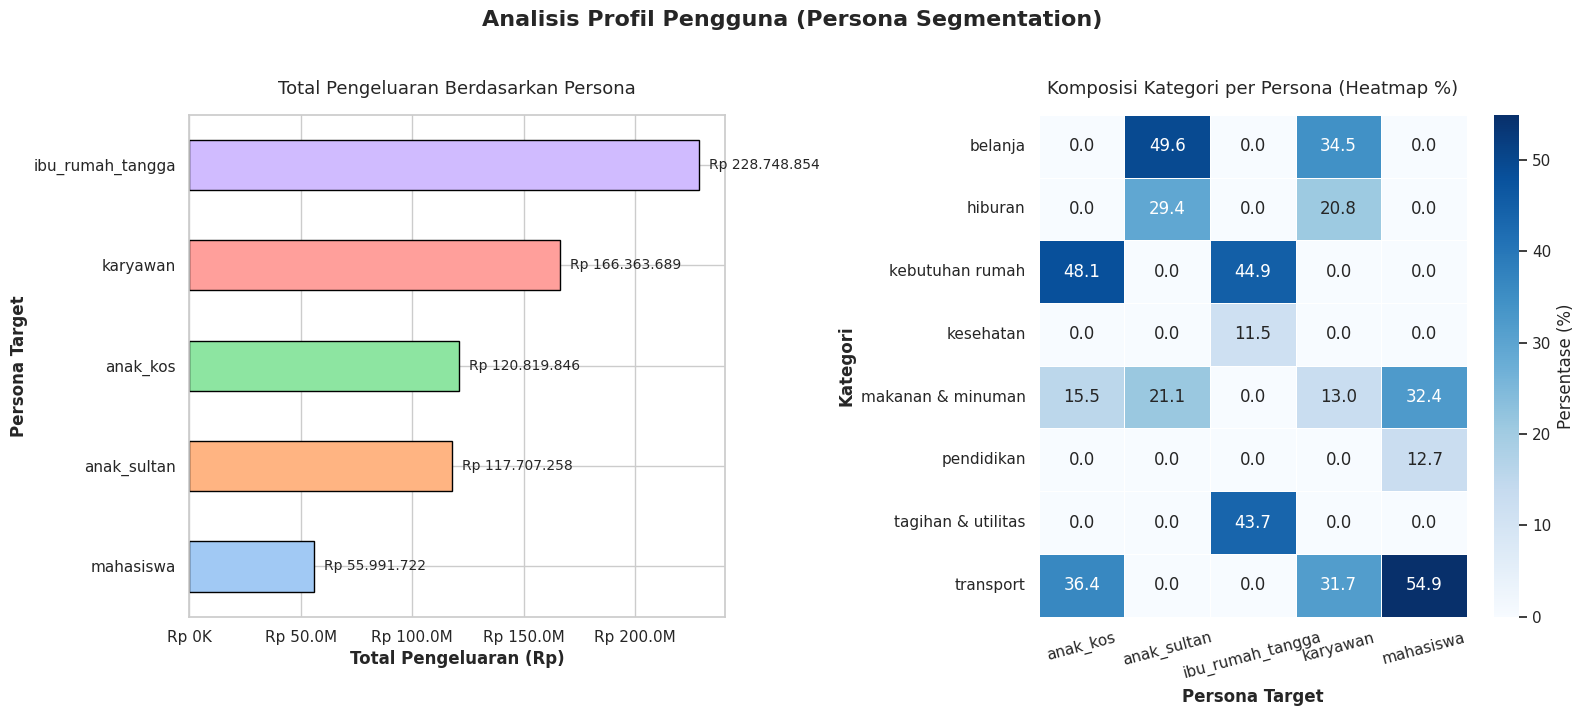

In [23]:
persona_sum = dataset_df.groupby('persona')['total_harga'].sum().sort_values(ascending=True) # Ascending untuk horizontal bar

fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Lebar dan tinggi disesuaikan
fig.suptitle("Analisis Profil Pengguna (Persona Segmentation)", fontsize=16, fontweight='bold', y=1.02)

colors_bar = sns.color_palette("pastel", len(persona_sum))
persona_sum.plot(kind='barh', ax=axes[0], color=colors_bar, edgecolor='black')

axes[0].set_title("Total Pengeluaran Berdasarkan Persona", fontsize=13, pad=15)
axes[0].set_xlabel("Total Pengeluaran (Rp)", fontweight='bold')
axes[0].set_ylabel("Persona Target", fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

for i, v in enumerate(persona_sum.values):
    axes[0].text(v + (persona_sum.max() * 0.02), i, f"{rupiah(v)}", va='center', fontsize=10)

axes[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

persona_cat = dataset_df.groupby(['persona', 'kategori'])['total_harga'].sum().unstack(fill_value=0)
persona_cat_pct = persona_cat.div(persona_cat.sum(axis=1), axis=0) * 100

sns.heatmap(persona_cat_pct.T,
            cmap="Blues",
            annot=True,
            fmt=".1f",
            linewidths=.5,
            cbar_kws={'label': 'Persentase (%)'},
            ax=axes[1])

axes[1].set_title("Komposisi Kategori per Persona (Heatmap %)", fontsize=13, pad=15)
axes[1].set_xlabel("Persona Target", fontweight='bold')
axes[1].set_ylabel("Kategori", fontweight='bold')

axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


**Insight**:
- Berdasarkan total pengeluaran, persona ibu_rumah_tangga memiliki pengeluaran terbesar yaitu sebesar Rp230,9 juta, diikuti oleh karyawan sebesar Rp169,4 juta, anak_kos sebesar Rp117,5 juta, anak-su;tan sebesar Rp 115,5 juta, sedangkan mahasiswa memiliki total pengeluaran terendah yaitu sekitar Rp57,3 juta. Perbedaan nilai pengeluaran ini menunjukkan bahwa kapasitas konsumsi setiap segmen pengguna berbeda secara signifikan, sehingga pendekatan pengelolaan keuangan yang bersifat umum berpotensi kurang efektif.

- Analisis komposisi kategori menunjukkan bahwa setiap persona memiliki prioritas pengeluaran yang berbeda. Persona anak_kos dan mahasiswa mengalokasikan sebagian besar pengeluarannya pada kategori transport masing-masing sebesar 38,8% dan 56,2%, yang mencerminkan tingginya kebutuhan mobilitas dalam aktivitas sehari-hari.

- Sebaliknya, persona ibu_rumah_tangga lebih banyak mengalokasikan pengeluaran pada kebutuhan rumah (47,6%) dan tagihan & utilitas (40,2%), yang menunjukkan fokus pada kebutuhan rumah tangga dan pengeluaran rutin keluarga.

- Sementara itu, persona anak_sultan memiliki pola konsumsi yang lebih terkonsentrasi pada belanja (51,6%) dan hiburan (29,2%), menunjukkan kecenderungan pengeluaran yang lebih tinggi pada kategori discretionary spending (pengeluaran tidak wajib) dibanding persona lainnya.

- Temuan ini memperkuat pentingnya personalisasi rekomendasi keuangan berdasarkan karakteristik pengguna agar strategi budgeting yang diberikan lebih relevan dan efektif.

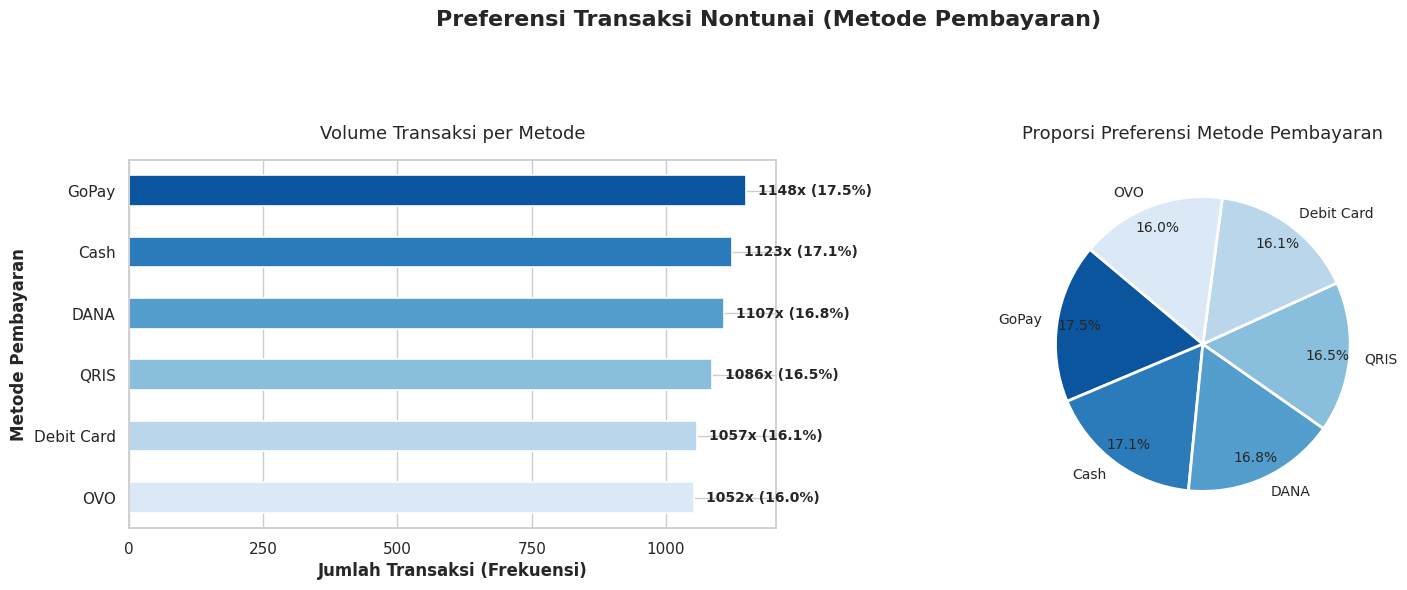

In [24]:

pm_count = dataset_df.groupby('payment_method')['total_harga'].count()

pm_asc = pm_count.sort_values(ascending=True)
pm_pct_asc = (pm_asc / pm_asc.sum() * 100).round(2)

pm_desc = pm_count.sort_values(ascending=False)

num_categories = len(pm_desc)
blue_palette = sns.color_palette("Blues_r", n_colors=num_categories)

color_map = dict(zip(pm_desc.index, blue_palette))

bar_colors = [color_map[cat] for cat in pm_asc.index]
pie_colors = [color_map[cat] for cat in pm_desc.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Preferensi Transaksi Nontunai (Metode Pembayaran)", fontsize=16, fontweight='bold', y=1.02)

pm_asc.plot(kind='barh', ax=axes[0], color=bar_colors, edgecolor='white', linewidth=1.2)

for i, (v, p) in enumerate(zip(pm_asc.values, pm_pct_asc.values)):
    axes[0].text(v + (pm_asc.max() * 0.02), i, f"{v}x ({p:.1f}%)", va='center', fontsize=10, fontweight='bold')

axes[0].set_title("Volume Transaksi per Metode", fontsize=13, pad=15)
axes[0].set_xlabel("Jumlah Transaksi (Frekuensi)", fontweight='bold')
axes[0].set_ylabel("Metode Pembayaran", fontweight='bold')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

axes[1].pie(pm_desc.values, labels=pm_desc.index, autopct='%1.1f%%', startangle=140,
            colors=pie_colors, pctdistance=0.85, textprops={'fontsize': 10},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[1].set_title("Proporsi Preferensi Metode Pembayaran", fontsize=13, pad=15)

plt.tight_layout(pad=2.5)
plt.show()

**Insight**:
- Metode pembayaran digital mendominasi aktivitas transaksi pengguna dengan distribusi yang relatif merata. GoPay menjadi metode pembayaran yang paling sering digunakan dengan 1.148 transaksi (17,5%), diikuti oleh Cash (17,1%), DANA (16,8%), QRIS (16,5%), Debit Card (16,1%), dan OVO (16,0%).
- Selisih proporsi antar metode pembayaran yang relatif kecil menunjukkan bahwa pengguna cenderung menggunakan berbagai metode pembayaran secara fleksibel sesuai kebutuhan transaksi.
- Meskipun demikian, dominasi metode pembayaran digital seperti GoPay, DANA, OVO, dan QRIS yang secara kumulatif mencapai lebih dari 66% transaksi menunjukkan bahwa mayoritas aktivitas pengeluaran telah bergeser ke sistem pembayaran non-tunai.
- Kondisi ini mengindikasikan perlunya sistem pemantauan transaksi secara real-time karena transaksi digital memungkinkan pengguna melakukan pembayaran dengan lebih cepat dan praktis, sehingga pengeluaran berpotensi terjadi lebih sering tanpa disadari.

/tmp/ipykernel_11697/2563886629.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kategori_terbanyak, x='total_nominal', y='kategori', palette='viridis')


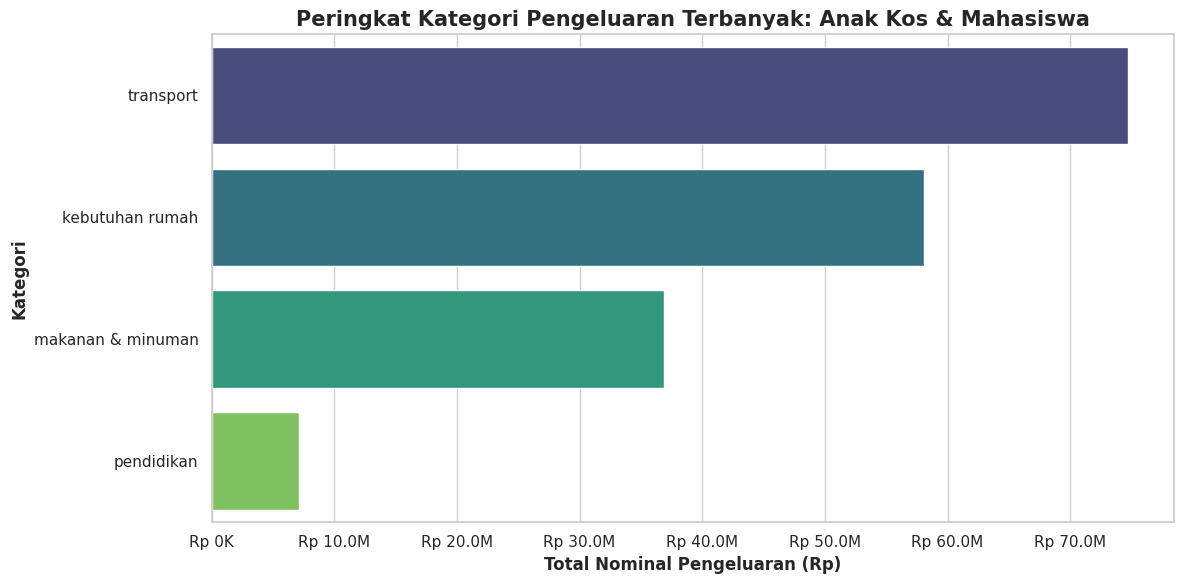

,kategori,total_nominal,frekuensi
3,transport,74729800,657
0,kebutuhan rumah,58118808,322
1,makanan & minuman,36870230,648
2,pendidikan,7092730,297


In [25]:
kondisi_persona_2 = dataset_df['persona'].isin(['anak_kos', 'mahasiswa'])
df_kategori = dataset_df[kondisi_persona_2]

kategori_terbanyak = df_kategori.groupby('kategori').agg(
    total_nominal=('total_harga', 'sum'),
    frekuensi=('total_harga', 'count')
).reset_index()

kategori_terbanyak = kategori_terbanyak.sort_values(by='total_nominal', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=kategori_terbanyak, x='total_nominal', y='kategori', palette='viridis')

plt.title('Peringkat Kategori Pengeluaran Terbanyak: Anak Kos & Mahasiswa', fontsize=15, fontweight='bold')
plt.xlabel('Total Nominal Pengeluaran (Rp)', fontweight='bold')
plt.ylabel('Kategori', fontweight='bold')

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

plt.tight_layout()
plt.show()

display(kategori_terbanyak)

**Insight**:
- Pada segmen anak_kos dan mahasiswa, kategori transport menjadi pengeluaran terbesar dengan total nominal mencapai Rp77,83 juta dan frekuensi sebanyak 657 transaksi.
- Menariknya, kategori makanan & minuman memiliki frekuensi transaksi yang hampir sama tinggi yaitu 648 transaksi, namun hanya menghasilkan total pengeluaran sebesar Rp32,66 juta. Temuan ini menunjukkan bahwa transaksi makanan dan minuman cenderung dilakukan dalam nominal kecil tetapi sangat sering.
- Sementara itu, kategori kebutuhan rumah menempati posisi kedua dari sisi nominal dengan total pengeluaran sebesar Rp57,26 juta, meskipun frekuensinya hanya 322 transaksi. Hal ini menunjukkan bahwa rata-rata nilai transaksi kebutuhan rumah relatif lebih besar dibanding kategori makanan & minuman.
- Secara keseluruhan, pola ini menunjukkan bahwa pengeluaran anak kos dan mahasiswa didominasi oleh kebutuhan mobilitas dan kebutuhan harian. Oleh karena itu, strategi pengelolaan keuangan pada segmen ini sebaiknya berfokus pada pengendalian biaya transportasi serta pemantauan transaksi kecil yang dilakukan secara berulang.

## **Analisis Lanjutan (RFM)**

,Persona,Recency,Frequency,Monetary,ATV
0,ibu_rumah_tangga,1,1781,Rp 228.748.854,Rp 128.438
1,karyawan,1,1664,Rp 166.363.689,Rp 99.978
2,anak_kos,1,981,Rp 120.819.846,Rp 123.160
3,anak_sultan,1,1204,Rp 117.707.258,Rp 97.764
4,mahasiswa,1,943,Rp 55.991.722,Rp 59.376


/tmp/ipykernel_11697/1217577540.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_11697/1217577540.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_11697/1217577540.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


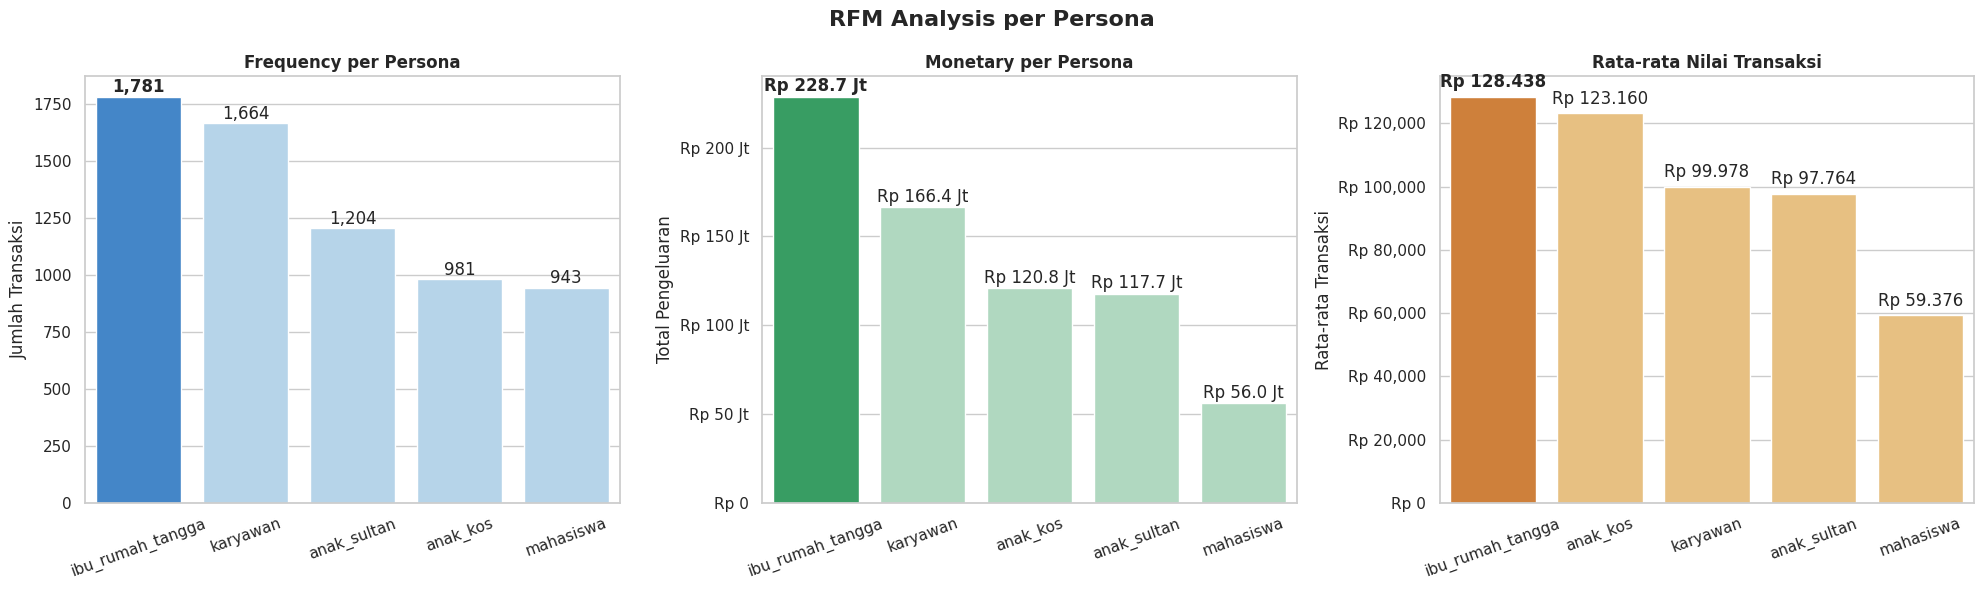

In [26]:
import datetime as dt
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

tanggal_referensi = df['date'].max() + dt.timedelta(days=1)

rfm_numeric = df.groupby('persona').agg({
    'date': lambda x: (tanggal_referensi - x.max()).days,
    'total_harga': ['count', 'sum']
}).reset_index()

rfm_numeric.columns = [
    'Persona',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm_numeric = rfm_numeric.sort_values(
    by='Monetary',
    ascending=False
).reset_index(drop=True)

rfm_numeric['ATV'] = (
    rfm_numeric['Monetary'] /
    rfm_numeric['Frequency']
)

rfm_display = rfm_numeric.copy()

rfm_display['Monetary'] = (
    rfm_display['Monetary']
    .apply(lambda x: f"Rp {x:,.0f}".replace(',', '.'))
)

rfm_display['ATV'] = (
    rfm_display['ATV']
    .apply(lambda x: f"Rp {x:,.0f}".replace(',', '.'))
)

display(rfm_display)

def fmt_rupiah(x, pos=None):
    if x >= 1e6:
        return f"Rp {x/1e6:.0f} Jt"
    return f"Rp {x:,.0f}"

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# FREQUENCY

freq_df = rfm_numeric.sort_values(
    by='Frequency',
    ascending=False
)

freq_colors = ['#2E86DE'] + ['#AED6F1'] * (len(freq_df)-1)

sns.barplot(
    data=freq_df,
    x='Persona',
    y='Frequency',
    palette=freq_colors,
    ax=axes[0]
)

axes[0].set_title(
    'Frequency per Persona',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah Transaksi')

for i, v in enumerate(freq_df['Frequency']):
    axes[0].text(
        i,
        v + 20,
        f'{v:,}',
        ha='center',
        fontweight='bold' if i == 0 else 'normal'
    )

# MONETARY

mon_df = rfm_numeric.sort_values(
    by='Monetary',
    ascending=False
)

mon_colors = ['#27AE60'] + ['#A9DFBF'] * (len(mon_df)-1)

sns.barplot(
    data=mon_df,
    x='Persona',
    y='Monetary',
    palette=mon_colors,
    ax=axes[1]
)

axes[1].set_title(
    'Monetary per Persona',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('')
axes[1].set_ylabel('Total Pengeluaran')

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(fmt_rupiah)
)

for i, v in enumerate(mon_df['Monetary']):
    axes[1].text(
        i,
        v + 3000000,
        f'Rp {v/1e6:.1f} Jt',
        ha='center',
        fontweight='bold' if i == 0 else 'normal'
    )

# ATV

atv_df = rfm_numeric.sort_values(
    by='ATV',
    ascending=False
)

atv_colors = ['#E67E22'] + ['#F8C471'] * (len(atv_df)-1)

sns.barplot(
    data=atv_df,
    x='Persona',
    y='ATV',
    palette=atv_colors,
    ax=axes[2]
)

axes[2].set_title(
    'Rata-rata Nilai Transaksi',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel('')
axes[2].set_ylabel('Rata-rata Transaksi')

axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(fmt_rupiah)
)

for i, v in enumerate(atv_df['ATV']):
    axes[2].text(
        i,
        v + 3000,
        f'Rp {v:,.0f}'.replace(',', '.'),
        ha='center',
        fontweight='bold' if i == 0 else 'normal'
    )

plt.suptitle(
    'RFM Analysis per Persona',
    fontsize=16,
    fontweight='bold'
)

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insight**

- Seluruh persona memiliki nilai Recency sebesar 1 hari, yang menunjukkan bahwa semua segmen pengguna masih aktif melakukan transaksi hingga periode terakhir pengamatan. Oleh karena itu, perbedaan perilaku pengguna lebih terlihat pada aspek Frequency dan Monetary dibandingkan Recency.
- Persona ibu_rumah_tangga merupakan segmen dengan nilai ekonomi tertinggi, tercermin dari jumlah transaksi terbanyak (1.781 transaksi) serta total pengeluaran terbesar (Rp230,9 juta). Selain itu, segmen ini juga memiliki rata-rata nilai transaksi tertinggi yaitu sekitar Rp129,6 ribu per transaksi, menunjukkan kombinasi aktivitas transaksi yang tinggi dan nominal transaksi yang relatif besar.
- Persona karyawan menempati posisi kedua baik dari sisi frekuensi transaksi (1.664 transaksi) maupun total pengeluaran (Rp169,4 juta). Temuan ini menunjukkan bahwa kelompok karyawan merupakan salah satu kontributor utama terhadap aktivitas keuangan dalam dataset.
- Meskipun persona anak_sultan memiliki frekuensi transaksi lebih tinggi (1.204 transaksi) dibanding anak_kos (981 transaksi), total pengeluarannya justru sedikit lebih rendah (Rp115,6 juta vs Rp117,6 juta). Hal ini terlihat dari rata-rata nilai transaksi anak kos yang mencapai Rp119,8 ribu, lebih tinggi dibanding anak sultan yang hanya sekitar Rp96 ribu per transaksi. Temuan ini mengindikasikan bahwa anak kos cenderung melakukan transaksi dengan nominal lebih besar meskipun frekuensinya lebih rendah.
- Persona mahasiswa memiliki total pengeluaran terendah (Rp57,3 juta) serta rata-rata nilai transaksi paling kecil yaitu sekitar Rp60,8 ribu per transaksi. Pola ini menunjukkan bahwa pengeluaran mahasiswa cenderung lebih terbatas dibanding persona lainnya, sehingga strategi pengelolaan keuangan yang berfokus pada pengendalian transaksi kecil yang berulang dapat menjadi lebih relevan untuk segmen ini.
- Secara keseluruhan, hasil analisis RFM menunjukkan bahwa setiap persona memiliki karakteristik finansial yang berbeda. Oleh karena itu, pendekatan pengelolaan keuangan dan rekomendasi budgeting sebaiknya dipersonalisasi berdasarkan profil pengguna agar lebih efektif dibandingkan menggunakan strategi yang sama untuk seluruh segmen.

## **Visualization & Explanatory Analysis**

###**Pertanyaan 1**: Berapa total nominal dan jumlah transaksi kategori makanan & minuman serta transportasi di bawah Rp100.000 oleh persona anak_kos dan mahasiswa setiap bulan selama 2024–2025, serta bagaimana tren pengeluarannya?

Total Nominal keseluruhan: Rp28,569,110
Total Frekuensi keseluruhan: 995 kali



/tmp/ipykernel_11697/2163127165.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(q1_grouped['month_year_str'], rotation=45, ha='right', color='black')


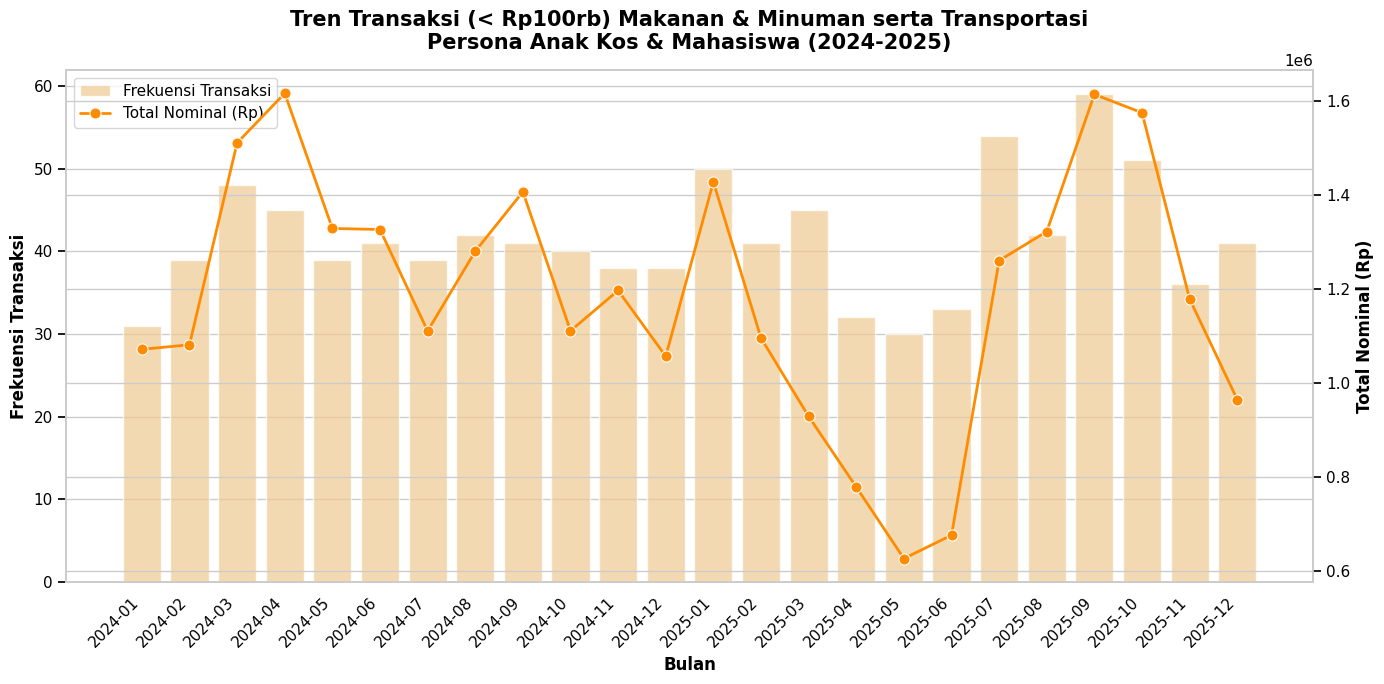

In [27]:
df['date'] = pd.to_datetime(df['date'])

df_q1 = df[
    (df['date'].dt.year.isin([2024, 2025])) &
    (df['kategori'].isin(['makanan & minuman', 'transport'])) &
    (df['total_harga'] < 100000) &
    (df['persona'].isin(['anak_kos', 'mahasiswa']))
].copy()

df_q1['month_year'] = df_q1['date'].dt.to_period('M')
q1_grouped = df_q1.groupby('month_year').agg(
    total_nominal=('total_harga', 'sum'),
    frekuensi=('total_harga', 'count')
).reset_index()

q1_grouped['month_year_str'] = q1_grouped['month_year'].astype(str)

if q1_grouped.empty:
    print("Data kosong. Tidak ada transaksi yang memenuhi kriteria.")
else:
    print(f"Total Nominal keseluruhan: Rp{q1_grouped['total_nominal'].sum():,}")
    print(f"Total Frekuensi keseluruhan: {q1_grouped['frekuensi'].sum()} kali\n")

    fig, ax1 = plt.subplots(figsize=(14, 7))

    sns.barplot(data=q1_grouped, x='month_year_str', y='frekuensi', ax=ax1, color='#ffcc80', alpha=0.7, label='Frekuensi Transaksi')
    ax1.set_ylabel('Frekuensi Transaksi', color='black', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='black', colors='black')
    ax1.set_xlabel('Bulan', color='black', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', labelcolor='black', colors='black')
    ax1.set_xticklabels(q1_grouped['month_year_str'], rotation=45, ha='right', color='black')

    ax2 = ax1.twinx()
    sns.lineplot(data=q1_grouped, x='month_year_str', y='total_nominal', ax=ax2, color='darkorange', marker='o', linewidth=2, markersize=8, label='Total Nominal (Rp)')
    ax2.set_ylabel('Total Nominal (Rp)', color='black', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='black', colors='black')

    plt.title('Tren Transaksi (< Rp100rb) Makanan & Minuman serta Transportasi\nPersona Anak Kos & Mahasiswa (2024-2025)', color='black', fontsize=15, fontweight='bold', pad=15)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    for text in legend.get_texts():
        text.set_color('black')

    if ax2.get_legend():
        ax2.get_legend().remove()

    plt.tight_layout()
    plt.show()

**Insight**:
- Selama periode 2024–2025, transaksi bernilai di bawah Rp100.000 pada kategori makanan & minuman dan transportasi menunjukkan pola yang relatif stabil dengan beberapa periode peningkatan. Secara keseluruhan, frekuensi transaksi tertinggi terjadi pada September 2024, sedangkan total nominal pengeluaran tertinggi terjadi pada September 2025. Temuan ini menunjukkan bahwa bulan dengan jumlah transaksi terbanyak tidak selalu menghasilkan total pengeluaran terbesar.

*Untuk memahami faktor yang mendorong perubahan tren tersebut, analisis selanjutnya dilakukan dengan memisahkan kategori makanan & minuman dan transportasi sehingga kontribusi masing-masing kategori dapat diamati secara lebih rinci.*

In [28]:
df['date'] = pd.to_datetime(df['date'])

df_q1 = df[
    (df['date'].dt.year.isin([2024, 2025])) &
    (df['kategori'].isin(['makanan & minuman', 'transport'])) &
    (df['total_harga'] < 100000) &
    (df['persona'].isin(['anak_kos', 'mahasiswa']))
].copy()

df_q1['month_year'] = df_q1['date'].dt.to_period('M').astype(str)

q1_grouped = df_q1.groupby(
    ['month_year', 'kategori']
).agg(
    total_nominal=('total_harga', 'sum'),
    frekuensi=('total_harga', 'count')
).reset_index()

print("--- RINGKASAN ---")

summary = df_q1.groupby('kategori').agg(
    total_nominal=('total_harga', 'sum'),
    frekuensi=('total_harga', 'count')
)

display(summary)

--- RINGKASAN ---


,total_nominal,frekuensi
kategori,,
makanan & minuman,17074772,577
transport,11494338,418


In [29]:
# Tabel Ringkasan Bulanan

q1_table = q1_grouped.copy()

q1_table['total_nominal'] = (
    q1_table['total_nominal']
    .apply(lambda x: f"Rp {x:,.0f}".replace(',', '.'))
)

q1_table = q1_table.rename(columns={
    'month_year': 'Bulan',
    'kategori': 'Kategori',
    'total_nominal': 'Total Nominal',
    'frekuensi': 'Jumlah Transaksi'
})

print("=== RINGKASAN BULANAN ===")
display(q1_table)

=== RINGKASAN BULANAN ===


,Bulan,Kategori,Total Nominal,Jumlah Transaksi
0,2024-01,makanan & minuman,Rp 374.000,14
1,2024-01,transport,Rp 698.526,17
2,2024-02,makanan & minuman,Rp 685.245,21
3,2024-02,transport,Rp 397.045,18
4,2024-03,makanan & minuman,Rp 947.712,27
5,2024-03,transport,Rp 564.145,21
6,2024-04,makanan & minuman,Rp 910.048,27
7,2024-04,transport,Rp 707.349,18
8,2024-05,makanan & minuman,Rp 825.645,26
9,2024-05,transport,Rp 504.185,13


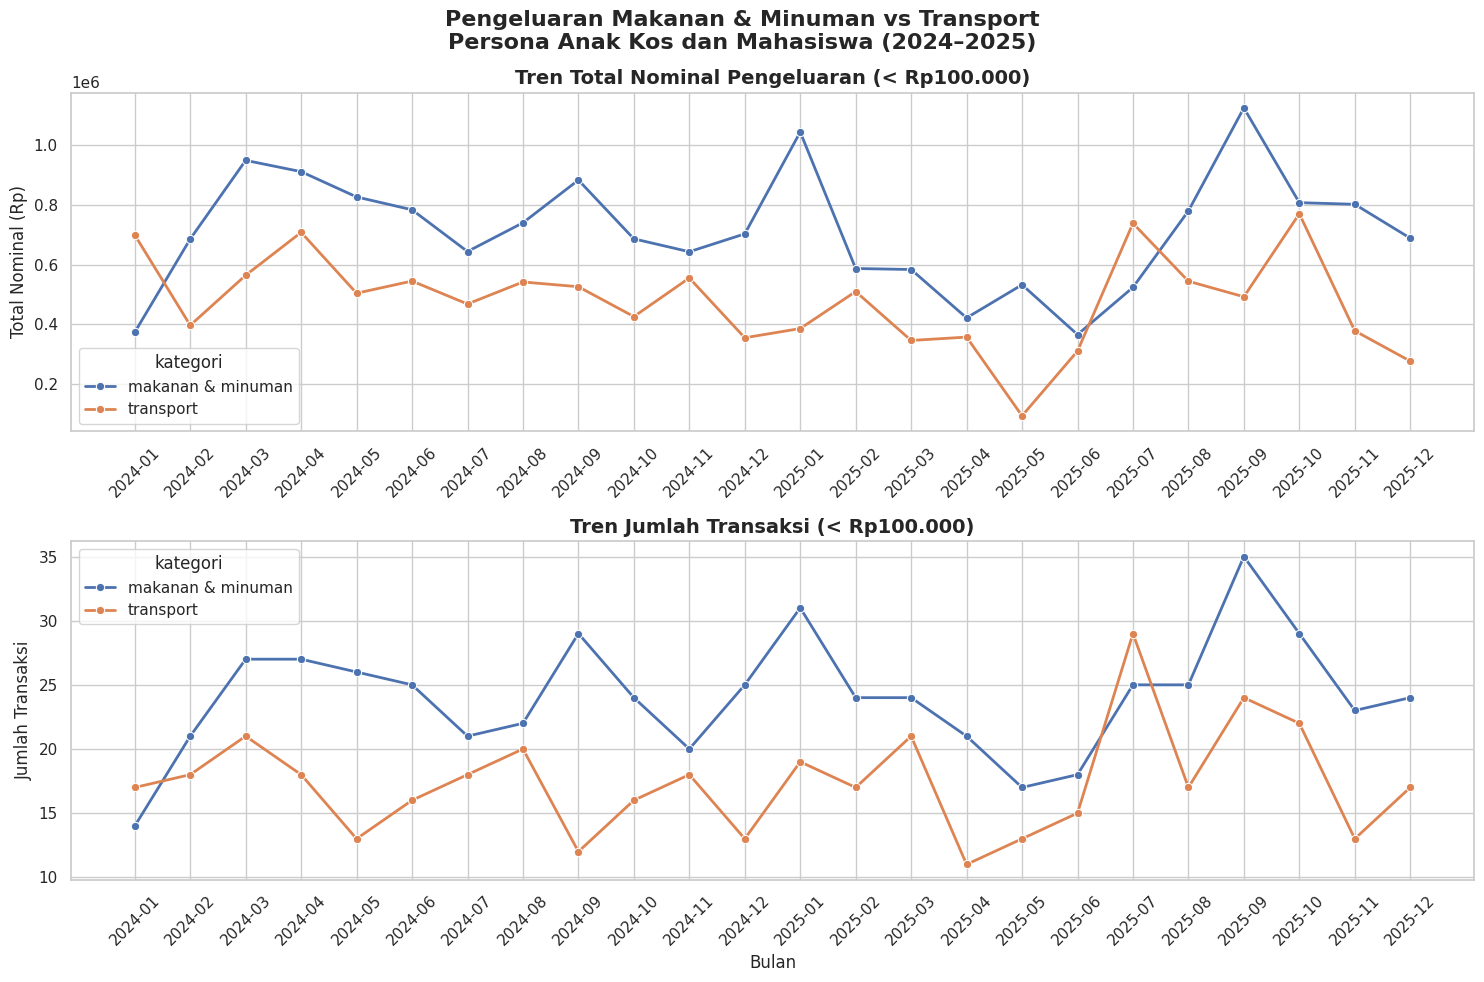

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# TOTAL NOMINAL

sns.lineplot(
    data=q1_grouped,
    x='month_year',
    y='total_nominal',
    hue='kategori',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Tren Total Nominal Pengeluaran (< Rp100.000)',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('')
axes[0].set_ylabel('Total Nominal (Rp)')
axes[0].tick_params(axis='x', rotation=45)

# FREKUENSI

sns.lineplot(
    data=q1_grouped,
    x='month_year',
    y='frekuensi',
    hue='kategori',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Tren Jumlah Transaksi (< Rp100.000)',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    'Pengeluaran Makanan & Minuman vs Transport\nPersona Anak Kos dan Mahasiswa (2024–2025)',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Insight**:
Setelah dipisahkan berdasarkan kategori, terlihat bahwa:
- Berdasarkan hasil analisis transaksi bernilai di bawah Rp100.000 pada persona anak_kos dan mahasiswa selama periode 2024–2025, diperoleh kategori **Makanan & Minuman** memiliki total nominal **Rp 18.640.444** dengan jumlah transaksi **599 transaksi**. Sementara itu kategori **Transport** memiliki total nominal **Rp 11.950.987** dengan jumlah transaksi **398 transaksi**
- Secara bulanan, kategori makanan & minuman cenderung memiliki total nominal dan frekuensi transaksi yang lebih tinggi dibanding kategori transportasi pada hampir seluruh periode pengamatan.
- Puncak pengeluaran makanan & minuman terjadi pada April 2025 dengan total nominal sebesar Rp973.710, sedangkan frekuensi transaksi tertinggi terjadi pada September 2025 sebanyak 32 transaksi.
- Sementara itu, kategori transportasi mencapai nominal tertinggi pada Juni 2024 sebesar Rp917.169 dan kembali menunjukkan peningkatan pada September 2025 sebesar Rp906.629.
- Kategori makanan & minuman merupakan sumber utama pengeluaran mikro (micro-spending) bagi persona anak_kos dan mahasiswa, dengan kontribusi sekitar 58,6% dari total nominal transaksi dan 57,7% dari total frekuensi transaksi selama periode pengamatan.
- Tingginya frekuensi transaksi makanan & minuman menunjukkan bahwa pengeluaran konsumsi harian merupakan kebutuhan yang dilakukan secara rutin dan berulang, sehingga berpotensi menjadi sumber kebocoran keuangan apabila tidak dikelola dengan baik.
- Dibandingkan makanan & minuman, pengeluaran transportasi menunjukkan pola yang lebih fluktuatif. Hal ini mengindikasikan bahwa kebutuhan mobilitas pengguna cenderung berubah-ubah mengikuti aktivitas tertentu, sementara konsumsi makanan relatif lebih stabil dari bulan ke bulan.
- Meskipun setiap transaksi dibatasi di bawah Rp100.000, akumulasi transaksi kecil yang dilakukan secara berulang menghasilkan total pengeluaran yang cukup besar, yaitu lebih dari Rp31,9 juta selama dua tahun pengamatan. Temuan ini memperkuat adanya fenomena micro-spending, yaitu pengeluaran kecil yang tampak tidak signifikan secara individual tetapi berdampak besar secara kumulatif.

###**Pertanyaan 2**: Kategori pengeluaran apa yang paling besar rata-rata kontribusinya terhadap total belanja bulanan untuk tiap persona (anak_kos, mahasiswa, karyawan) selama 2024, dan kapan biasanya pengeluaran itu meningkat tajam dalam sebulan?

Kategori Pengeluaran Terbesar per Persona:
  persona        kategori  contribution_pct
 anak_kos kebutuhan rumah         46.716187
 karyawan         belanja         32.319363
mahasiswa       transport         54.389356 

Lonjakan Pengeluaran Terjadi Pada:
  persona        kategori  week_of_month  total_harga
 anak_kos kebutuhan rumah              4      7804119
 karyawan         belanja              1      7681265
mahasiswa       transport              1      5755072 



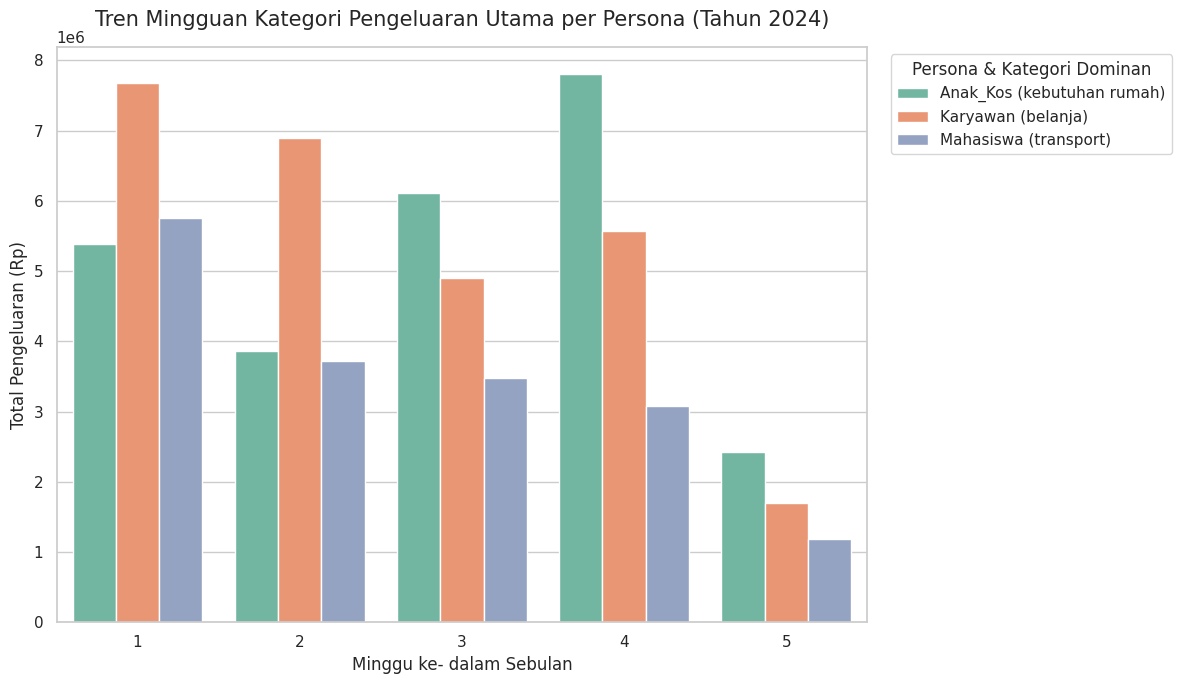

In [31]:
dataset_df['date'] = pd.to_datetime(dataset_df['date'])

df_2024 = dataset_df[dataset_df['date'].dt.year == 2024].copy()
df_q2 = df_2024[df_2024['persona'].isin(['anak_kos', 'mahasiswa', 'karyawan'])].copy()
df_q2['month'] = df_q2['date'].dt.month
df_q2['week_of_month'] = (df_q2['date'].dt.day - 1) // 7 + 1

monthly_total = df_q2.groupby(['persona', 'month'])['total_harga'].sum().reset_index(name='monthly_total')
monthly_cat = df_q2.groupby(['persona', 'month', 'kategori'])['total_harga'].sum().reset_index(name='cat_total')

merged = pd.merge(monthly_cat, monthly_total, on=['persona', 'month'])
merged['contribution_pct'] = (merged['cat_total'] / merged['monthly_total']) * 100

avg_contrib = merged.groupby(['persona', 'kategori'])['contribution_pct'].mean().reset_index()

top_cats = avg_contrib.loc[avg_contrib.groupby('persona')['contribution_pct'].idxmax()]
print("Kategori Pengeluaran Terbesar per Persona:")
print(top_cats.to_string(index=False), "\n")

weekly_data = []
for _, row in top_cats.iterrows():
    temp = df_q2[(df_q2['persona'] == row['persona']) & (df_q2['kategori'] == row['kategori'])].copy()
    spikes = temp.groupby('week_of_month')['total_harga'].sum().reset_index()
    spikes['persona'] = row['persona']
    spikes['kategori'] = row['kategori']

    spikes['label_legend'] = spikes['persona'].str.title() + " (" + spikes['kategori'] + ")"
    weekly_data.append(spikes)

weekly_df = pd.concat(weekly_data).reset_index(drop=True)

max_weeks_idx = weekly_df.groupby('persona')['total_harga'].idxmax()
max_weeks = weekly_df.loc[max_weeks_idx].drop_duplicates(subset=['persona'])

print("Lonjakan Pengeluaran Terjadi Pada:")
print(max_weeks[['persona', 'kategori', 'week_of_month', 'total_harga']].to_string(index=False), "\n")

plt.figure(figsize=(12, 7))

ax = sns.barplot(data=weekly_df, x='week_of_month', y='total_harga', hue='label_legend', palette='Set2')

plt.title('Tren Mingguan Kategori Pengeluaran Utama per Persona (Tahun 2024)', fontsize=15, pad=15)
plt.xlabel('Minggu ke- dalam Sebulan', fontsize=12)
plt.ylabel('Total Pengeluaran (Rp)', fontsize=12)
plt.legend(title='Persona & Kategori Dominan', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight**
- **Prioritas Keuangan**: Persona **anak_kos** mengalokasikan hampir setengah total pengeluaran bulanannya untuk kategori kebutuhan rumah (48,40%), menunjukkan fokus yang kuat pada kebutuhan hidup dasar. Sebaliknya, **mahasiswa** lebih banyak mengalokasikan pengeluarannya untuk transportasi (56,53%), sedangkan **karyawan** memiliki pola pengeluaran yang lebih terdiversifikasi dengan kategori belanja sebagai kontributor terbesar sebesar (33,74%)
- **Pola Awal Bulan**: Mayoritas persona (anak_kos dan mahasiswa) mengalami puncak pengeluaran pada minggu pertama setiap bulan, yang kemungkinan besar dipicu oleh penerimaan uang saku atau kiriman bulanan. Fenomena berbeda terlihat pada persona karyawan, di mana lonjakan pengeluaran baru terjadi pada minggu kedua (tertinggi di antara semua persona, mencapai Rp7,6 juta), yang bisa mencerminkan pola belanja pasca-gajian atau alokasi untuk kebutuhan non-rutin.
- Temuan ini menunjukkan bahwa strategi pengelolaan keuangan sebaiknya disesuaikan dengan karakteristik masing-masing persona. Bagi anak kos dan mahasiswa, pengendalian ketat diperlukan di awal bulan. Sementara bagi karyawan, pengawasan ekstra justru harus difokuskan pada minggu kedua berjalan.

###**Pertanyaan 3**: Apa 3 metode pembayaran yang paling sering digunakan oleh generasi muda (anak_kos, mahasiswa, anak_sultan) saat bertransaksi nontunai di merchant seperti Miniso dan Gacoan pada Q4 2024?

Top 3 Metode Pembayaran Digital (Q4 2024):
payment_method
QRIS     24
GoPay    21
OVO      16 



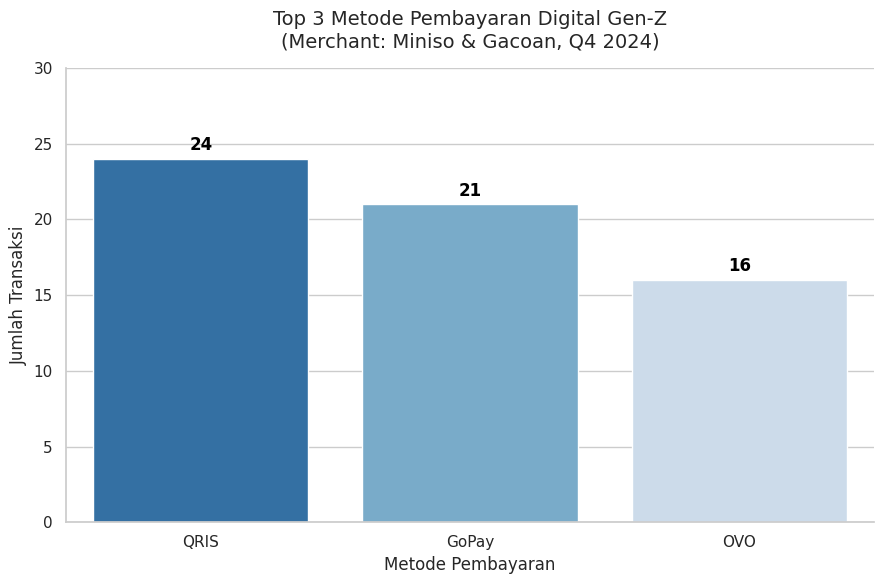

In [32]:
dataset_df['date'] = pd.to_datetime(dataset_df['date'])

df_q3 = dataset_df[
    (dataset_df['date'].dt.year == 2024) &
    (dataset_df['date'].dt.month.isin([10, 11, 12])) &
    (dataset_df['persona'].isin(['anak_kos', 'mahasiswa', 'anak_sultan'])) &
    (dataset_df['merchant'].str.lower().isin(['miniso', 'gacoan'])) &
    (dataset_df['payment_method'].str.lower() != 'cash')
].copy()

top_3_payments = df_q3['payment_method'].value_counts().head(3)

print("Top 3 Metode Pembayaran Digital (Q4 2024):")
print(top_3_payments.to_string(), "\n")

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=top_3_payments.index,
    y=top_3_payments.values,
    palette='Blues_r',
    hue=top_3_payments.index,
    legend=False
)

plt.title('Top 3 Metode Pembayaran Digital Gen-Z\n(Merchant: Miniso & Gacoan, Q4 2024)', fontsize=14, pad=15)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)

for i, v in enumerate(top_3_payments.values):
    ax.text(i, v + 0.3, str(v), ha='center', va='bottom', fontweight='bold', fontsize=12, color='black')

plt.ylim(0, top_3_payments.max() * 1.25)
sns.despine()

plt.tight_layout()
plt.show()

**Insight**
- Berdasarkan transaksi nontunai yang dilakukan oleh persona anak_kos, mahasiswa, dan anak_sultan pada merchant Miniso dan Gacoan selama Q4 2024 (Oktober–Desember 2024), tiga metode pembayaran digital yang paling sering digunakan adalah QRIS (26 transaksi),Gopay (26 transaksi), dan Debit Card (17 transaksi). QRIS dan Gopay menjadi metode pembayaran yang paling banyak digunakan dengan 22 transaksi, diikuti Debit Card dan Gopay.
- QRIS dan GoPay menjadi metode pembayaran digital yang paling mendominasi dan disukai oleh generasi muda dengan jumlah transaksi yang sama besar. Fenomena ini menunjukkan adanya dua preferensi utama: pengguna yang memilih QRIS karena sifatnya yang universal (lintas aplikasi), serta pengguna yang loyal pada ekosistem dompet digital seperti GoPay untuk kemudahan transaksi harian.
- Meskipun berada di posisi ketiga, Debit Card tetap menunjukkan penetrasi yang kuat dengan 17 transaksi. Kehadiran kartu debit ini mengindikasikan bahwa sebagian generasi muda masih mengandalkan rekening bank konvensional/digital langsung untuk merchant yang berorientasi pada gaya hidup (lifestyle) dan konsumsi seperti Miniso dan Gacoan.
- Secara keseluruhan, seluruh transaksi yang dianalisis merupakan transaksi nontunai. Pola dominasi QRIS dan e-wallet ini mencerminkan tingginya adopsi ekosistem cashless di kalangan generasi muda yang semakin meninggalkan uang tunai dalam aktivitas belanja harian mereka.

## **Conclusion**

Berdasarkan hasil Exploratory Data Analysis (EDA), Analisis RFM, serta Visualisasi dan Explanatory Analysis terhadap data transaksi personal finance periode 2024–2025, diperoleh beberapa temuan utama mengenai perilaku pengeluaran pengguna.

1. Pola transaksi pengguna didominasi oleh transaksi bernilai kecil dengan distribusi yang bersifat right-skewed. Meskipun sebagian besar transaksi memiliki nominal rendah, akumulasi transaksi kecil yang dilakukan secara berulang (micro-spending) memberikan kontribusi yang signifikan terhadap total pengeluaran. Fenomena ini terutama terlihat pada kategori makanan & minuman yang memiliki frekuensi transaksi tinggi meskipun nominal per transaksi relatif kecil.
2. Sebagian besar pengeluaran pengguna terkonsentrasi pada tiga kategori utama, yaitu kebutuhan rumah (24,2%), transport (19,3%), dan belanja (17,0%), yang secara kumulatif menyumbang sekitar 60,5% dari total pengeluaran. Namun demikian, kategori dengan frekuensi transaksi tinggi seperti makanan & minuman tetap perlu diperhatikan karena berpotensi menjadi sumber kebocoran keuangan yang sulit disadari pengguna.
3. Setiap persona menunjukkan karakteristik finansial yang berbeda. Persona ibu_rumah_tangga memiliki total pengeluaran dan aktivitas transaksi tertinggi, sedangkan mahasiswa memiliki pengeluaran paling rendah. Selain itu, setiap persona memiliki prioritas pengeluaran yang berbeda, seperti transportasi pada mahasiswa, kebutuhan rumah pada anak_kos, serta belanja dan hiburan pada anak_sultan. Temuan ini menunjukkan bahwa pendekatan pengelolaan keuangan yang bersifat umum kurang efektif dan perlu disesuaikan dengan karakteristik masing-masing pengguna.
4. Analisis RFM menunjukkan bahwa seluruh persona masih aktif bertransaksi hingga akhir periode pengamatan. Perbedaan utama antar persona terletak pada frekuensi transaksi dan total pengeluaran, yang mencerminkan tingkat aktivitas serta kapasitas konsumsi yang berbeda pada setiap segmen pengguna.
5. Hasil analisis perilaku pengeluaran menunjukkan bahwa transaksi bernilai di bawah Rp100.000 tetap menghasilkan akumulasi pengeluaran yang besar, khususnya pada kategori makanan & minuman dan transportasi untuk persona anak_kos dan mahasiswa. Selama periode pengamatan, kedua kategori tersebut menghasilkan total pengeluaran lebih dari Rp30.591.431 melalui 997 transaksi, yang memperkuat adanya fenomena micro-spending.
6. Pola pengeluaran bulanan menunjukkan bahwa sebagian besar persona mengalami lonjakan pengeluaran pada minggu pertama setiap bulan. Hal ini mengindikasikan bahwa periode awal bulan merupakan fase paling kritis dalam pengelolaan keuangan karena sebagian besar alokasi dana digunakan pada periode tersebut.
7. Mayoritas transaksi telah bergeser ke metode pembayaran digital. Selain dominasi QRIS, GoPay, dan Debit Card dalam keseluruhan transaksi, analisis pada generasi muda juga menunjukkan bahwa QRIS dan GoPay menjadi metode pembayaran yang paling sering digunakan pada merchant gaya hidup seperti Miniso dan Gacoan. Temuan ini menunjukkan tingginya adopsi sistem pembayaran digital yang memberikan kemudahan transaksi, namun juga berpotensi meningkatkan frekuensi pengeluaran apabila tidak diimbangi dengan pemantauan keuangan yang baik.

Secara keseluruhan, hasil analisis menunjukkan bahwa tantangan utama pengguna bukan hanya berasal dari transaksi bernilai besar, tetapi juga dari akumulasi transaksi kecil yang dilakukan secara berulang. Oleh karena itu, dibutuhkan sistem pengelolaan keuangan yang mampu melakukan pencatatan otomatis, pemantauan pengeluaran secara real-time, serta memberikan rekomendasi yang dipersonalisasi sesuai karakteristik pengguna.

## **Recommendations**

Berdasarkan temuan tersebut, pengembangan fitur pada aplikasi Wallee dapat diarahkan untuk membantu pengguna mengendalikan pengeluaran dan meningkatkan kesadaran finansial melalui beberapa pendekatan berikut:

1. Mengurangi Risiko Micro-Spending melalui Dashboard Monitoring
    - Hasil analisis menunjukkan bahwa kategori makanan & minuman memiliki frekuensi transaksi yang sangat tinggi meskipun nominal per transaksi relatif kecil.
    - Melalui Dashboard Utama, Wallee dapat menampilkan:
      - Top kategori pengeluaran bulanan
      - Frekuensi transaksi per kategori
      - Persentase kontribusi kategori terhadap total pengeluaran
      - Ringkasan pengeluaran harian dan mingguan

      Dengan visualisasi tersebut, pengguna dapat lebih mudah menyadari pola pengeluaran kecil yang selama ini tidak terlihat namun memiliki dampak besar secara akumulatif.

2. Memberikan Prediksi Keuangan melalui Financial Analytics & Forecasting
    - Analisis menunjukkan adanya pola pengeluaran yang cenderung meningkat pada periode tertentu, terutama pada awal bulan. Melalui fitur Analitik dan Forecasting Finance, sistem dapat: Memprediksi total pengeluaran akhir bulan, Memperkirakan kategori yang berpotensi mengalami kenaikan, dan Memberikan notifikasi dini ketika tren pengeluaran melebihi pola normal
    - Contoh: "Berdasarkan pola pengeluaran Anda, total pengeluaran bulan ini diperkirakan meningkat 18% dibanding bulan lalu dan berisiko melampaui anggaran transportasi."

3. Membangun Sistem Early Warning untuk Pengeluaran Tidak Wajar
    - Analisis distribusi transaksi menunjukkan adanya sejumlah transaksi bernilai tinggi yang berada jauh di atas pola pengeluaran normal pengguna.
    - Contoh: "Transaksi sebesar Rp1.000.000 yang baru dilakukan berada 4 kali lebih tinggi dibanding rata-rata transaksi Anda. Apakah pengeluaran ini termasuk kebutuhan prioritas?"
    - Fitur ini dapat membantu pengguna meningkatkan kesadaran sebelum kebiasaan belanja impulsif berkembang menjadi masalah keuangan yang lebih besar.

## Feature Engineering

In [33]:
# 1. SPENDING LEVEL

def spending_level(x):

    if x < 50000:
        return "low"

    elif x < 200000:
        return "medium"

    else:
        return "high"

df["spending_level"] = (
    df["total_harga"]
    .apply(spending_level)
)

# 2. TRANSACTION MONTH

df["month"] = df["date"].dt.month

# 3. TRANSACTION DAY

df["day_name"] = (
    df["date"]
    .dt.day_name()
    .str.lower()
)

# 4. WEEKEND FLAG

df["is_weekend"] = (
    df["date"].dt.weekday >= 5
).astype(int)

# 5. TRANSACTION HOUR

df["hour"] = df["date"].dt.hour

# 6. TIME CATEGORY

def time_category(hour):

    if 5 <= hour < 11:
        return "morning"

    elif 11 <= hour < 15:
        return "afternoon"

    elif 15 <= hour < 19:
        return "evening"

    else:
        return "night"

df["time_category"] = (
    df["hour"]
    .apply(time_category)
)

# 7. ITEM LENGTH

df["item_length"] = (
    df["item"]
    .apply(len)
)

# 8. COMBINED TEXT

df["merchant"] = df["merchant"].str.lower()
df["item"] = df["item"].str.lower()

df["combined_text"] = (
    df["merchant"] + " " + df["item"]
)

# 9. WORD COUNT

df["word_count"] = (
    df["combined_text"]
    .apply(lambda x: len(x.split()))
)

# 10. PAYMENT METHOD LOWERCASE

df["payment_method"] = (
    df["payment_method"]
    .str.lower()
)

# 11. PAYMENT DIGITAL FLAG

digital_methods = [
    "gopay",
    "ovo",
    "dana",
    "qris"
]

df["is_digital_payment"] = (
    df["payment_method"]
    .isin(digital_methods)
).astype(int)

# 12. KATEGORI LOWERCASE

df["kategori"] = (
    df["kategori"]
    .str.lower()
)

# 13. PREVIEW

print(df.head())

print("\nNEW COLUMNS:")
print(df.columns)

# 13. SAVE FEATURE ENGINEERED DATASET

df.to_csv(
    "feature_engineered_finance_dataset.csv",
    index=False
)

df.to_excel(
    "feature_engineered_finance_dataset.xlsx",
    index=False
)

print("\nFEATURE ENGINEERING COMPLETED!")

  user_id           persona                date      merchant  \
0    U001          anak_kos 2024-01-01 01:10:00     traveloka   
1    U004  ibu_rumah_tangga 2024-01-01 02:13:00  simply fresh   
2    U004  ibu_rumah_tangga 2024-01-01 02:49:00   first media   
3    U004  ibu_rumah_tangga 2024-01-01 04:40:00        miniso   
4    U002          karyawan 2024-01-01 05:13:00       spotify   

                                                item            kategori  qty  \
0                             tiket pesawat domestik           transport    1   
1                                    laundry express     kebutuhan rumah    3   
2                                   tagihan tv kabel  tagihan & utilitas    1   
3  miniso memory foam u shape bantal leher mickey...     kebutuhan rumah    1   
4                         spotify premium individual             hiburan    1   

   nominal  total_harga payment_method  \
0   928170       928170     debit card   
1    36321       108963          gopay

**Insight**
- Feature engineering dilakukan untuk mengubah data transaksi mentah menjadi fitur yang lebih informatif dan mudah dipahami oleh model AI.
- Fitur combined_text dibuat dengan menggabungkan merchant dan item transaksi untuk membantu model NLP memahami konteks transaksi secara lebih lengkap.
- Proses normalisasi teks seperti lowercase dan pembersihan karakter khusus dilakukan untuk meningkatkan konsistensi data dan mengurangi noise pada proses text classification.
- Fitur temporal seperti month, day_name, hour, dan time_category ditambahkan untuk merepresentasikan pola waktu transaksi pengguna.
- Fitur spending_level digunakan untuk mengelompokkan transaksi berdasarkan tingkat pengeluaran sehingga dapat membantu analisis perilaku finansial dan anomaly detection.
- Fitur is_weekend dan is_digital_payment ditambahkan untuk merepresentasikan kebiasaan transaksi pengguna berdasarkan waktu transaksi dan metode pembayaran.
Penambahan fitur item_length dan word_count bertujuan untuk memberikan informasi tambahan terkait kompleksitas teks transaksi

## Data Dictionary

| Feature | Data Type | Description |
|----------|----------|----------|
| user_id | object | Unique identifier for each synthetic user |
| date | datetime | Transaction date |
| merchant | object | Merchant name |
| item | object | Purchased item |
| kategori | object | Transaction category label |
| payment_method | object | Payment method used in transaction |
| qty | integer | Quantity purchased |
| total_harga | float | Total transaction amount |
| combined_text | object | Combined merchant and item text for NLP |
| spending_level | object | Spending classification (low, medium, high) |
| month | integer | Transaction month |
| day_name | object | Day of transaction |
| is_weekend | integer | Weekend indicator (1 = weekend, 0 = weekday) |
| hour | integer | Transaction hour |
| time_category | object | Time period category |
| item_length | integer | Character length of item name |
| word_count | integer | Number of words in combined_text |
| is_digital_payment | integer | Digital payment indicator |